In [90]:
!pip install kagglehub

# Customer Segmentation using RFM Analysis

## Project Overview

Customer segmentation helps businesses understand customer purchasing behavior and create targeted marketing strategies.

In this project, RFM Analysis (Recency, Frequency, Monetary) is used to divide customers into meaningful groups based on their purchasing habits.

The project covers:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- RFM Metric Calculation
- Customer Segmentation
- Business Insights
- Marketing Recommendations

In [91]:
import kagglehub

In [92]:
# Download latest version
path = kagglehub.dataset_download("fahadrehman07/retail-transaction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\harsh\.cache\kagglehub\datasets\fahadrehman07\retail-transaction-dataset\versions\1


In [93]:
import os

dataset_path = r"C:\Users\harsh\.cache\kagglehub\datasets\fahadrehman07\retail-transaction-dataset\versions\1"

print(os.listdir(dataset_path))

['Retail_Transaction_Dataset.csv']


# Import Required Libraries

The following libraries are used throughout the project.

- Pandas → Data Manipulation
- NumPy → Numerical Operations
- Matplotlib → Data Visualization
- Datetime → Date Calculations

# Load Dataset

The retail transaction dataset is loaded into a Pandas DataFrame for further analysis.

In [94]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from datetime import datetime

file_path = r"C:\Users\harsh\.cache\kagglehub\datasets\fahadrehman07\retail-transaction-dataset\versions\1\Retail_Transaction_Dataset.csv"

df = pd.read_csv(file_path)

df.head()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [95]:
df.tail()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
99995,726461,A,2,56.078258,7/17/2023 16:59,Credit Card,"3632 Darren Station Apt. 553\nEricaborough, RI...",Clothing,18.345145,91.581240
99996,328056,A,6,88.516406,5/30/2023 9:04,Credit Card,"821 Taylor Shoals\nEvansville, IL 70845",Electronics,3.995541,509.878179
99997,887304,B,4,72.385564,8/25/2023 7:59,Credit Card,"50653 Kara Lakes\nStephanieborough, RI 94492",Clothing,17.423979,239.092472
99998,326401,C,5,66.542239,2/5/2024 19:45,PayPal,"18756 Mcfarland Way Suite 866\nBarnettside, PR...",Electronics,14.345018,284.983717
99999,771566,C,5,38.087766,2/4/2024 11:53,Debit Card,"8046 Hull Drive\nPaulstad, GU 87218",Home Decor,2.966058,184.790305


# Dataset Overview

Before performing any analysis, it is important to understand the dataset structure.

This section examines:

- Number of rows and columns
- Data types
- Summary statistics
- Missing values

In [96]:
df.shape

(100000, 10)

In [97]:
df.columns

Index(['CustomerID', 'ProductID', 'Quantity', 'Price', 'TransactionDate',
       'PaymentMethod', 'StoreLocation', 'ProductCategory',
       'DiscountApplied(%)', 'TotalAmount'],
      dtype='object')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  object 
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  object 
 5   PaymentMethod       100000 non-null  object 
 6   StoreLocation       100000 non-null  object 
 7   ProductCategory     100000 non-null  object 
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 7.6+ MB


In [99]:
df.describe()

,CustomerID,Quantity,Price,DiscountApplied(%),TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,500463.982180,5.009290,55.067344,10.020155,248.334955
std,288460.917524,2.579808,25.971567,5.779534,184.554792
min,14.000000,1.000000,10.000430,0.000046,8.274825
25%,250693.750000,3.000000,32.549474,5.001013,95.163418
50%,499679.000000,5.000000,55.116789,10.030353,200.368393
75%,751104.750000,7.000000,77.456763,15.018367,362.009980
max,999997.000000,9.000000,99.999284,19.999585,896.141242


In [100]:
df.isnull().sum()

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64

# Data Cleaning

Raw data often contains duplicates, missing values, or incorrect data types.

Cleaning the data ensures accurate and reliable analysis.

The following steps are performed:

- Remove duplicate records
- Handle missing values
- Convert Transaction Date into datetime format

In [101]:
df.drop_duplicates(inplace = True)

In [102]:
df.isnull().sum()

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64

In [103]:
df.dropna(inplace=True)

In [104]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   CustomerID          100000 non-null  int64         
 1   ProductID           100000 non-null  object        
 2   Quantity            100000 non-null  int64         
 3   Price               100000 non-null  float64       
 4   TransactionDate     100000 non-null  datetime64[ns]
 5   PaymentMethod       100000 non-null  object        
 6   StoreLocation       100000 non-null  object        
 7   ProductCategory     100000 non-null  object        
 8   DiscountApplied(%)  100000 non-null  float64       
 9   TotalAmount         100000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 7.6+ MB


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand customer purchasing behavior.

Key questions answered:

- How many customers are there?
- What is the total revenue?
- Which payment methods are used?
- Which product categories are most popular?

In [106]:
print("Customers :", df["CustomerID"].nunique())
print("Transactions :", len(df))
print("Revenue :", df["TotalAmount"].sum())

Customers : 95215
Transactions : 100000
Revenue : 24833495.50638552


# RFM Analysis

RFM stands for:

**Recency**

How recently a customer made a purchase.

**Frequency**

How often a customer purchases.

**Monetary**

How much money the customer spends.

These three metrics are widely used for customer segmentation.

In [107]:
snapshot_date = df["TransactionDate"].max() + pd.Timedelta(days=1)

In [108]:
rfm = df.groupby("CustomerID").agg({
    "TransactionDate": lambda x: (snapshot_date - x.max()).days,
    "CustomerID": "count",
    "TotalAmount": "sum"
})

In [109]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [110]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
14,267,1,256.232791
42,346,1,502.656523
49,329,1,21.399047
59,28,2,249.492696
65,316,1,548.006625


In [111]:
rfm.describe()

,Recency,Frequency,Monetary
count,95215.000000,95215.000000,95215.000000
mean,179.806470,1.050255,260.814950
std,105.263337,0.226357,197.112734
min,1.000000,1.000000,8.274825
25%,88.000000,1.000000,99.493069
50%,178.000000,1.000000,210.700964
75%,271.000000,1.000000,378.626330
max,365.000000,4.000000,2002.072661


# RFM Scoring

Each customer receives a score from 1 to 5 for:

- Recency
- Frequency
- Monetary

These scores help classify customers into different behavioral segments.

In [112]:
rfm["R"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [113]:
rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [114]:
rfm["M"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [115]:
rfm["RFM_Score"] = (
    rfm["R"].astype(str)
    + rfm["F"].astype(str)
    + rfm["M"].astype(str)
)

In [116]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
14,267,1,256.232791,2,1,3,213
42,346,1,502.656523,1,1,5,115
49,329,1,21.399047,1,1,1,111
59,28,2,249.492696,5,5,3,553
65,316,1,548.006625,1,1,5,115


# Customer Segmentation

Customers are divided into business-friendly segments such as:

- Champions
- Loyal Customers
- Potential Loyalists
- New Customers
- At Risk
- Lost Customers

These segments help businesses create personalized marketing campaigns.

In [117]:
def segment_customer(row):
    r = int(row["R"])
    f = int(row["F"])
    m = int(row["M"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f <= 2:
        return "New Customers"

    elif r >= 3 and m >= 3:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [118]:
rfm["Segment"].value_counts()

Segment
Lost Customers         23691
At Risk                22207
Loyal Customers        16370
New Customers          14808
Potential Loyalists    10824
Champions               7315
Name: count, dtype: int64

In [119]:
rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

Segment
At Risk                5.736977e+06
Lost Customers         4.602958e+06
Potential Loyalists    3.943355e+06
New Customers          3.667746e+06
Champions              3.613594e+06
Loyal Customers        3.268865e+06
Name: Monetary, dtype: float64

In [120]:
rfm.groupby("Segment")["Monetary"].mean()

Segment
At Risk                258.340923
Champions              493.997877
Lost Customers         194.291428
Loyal Customers        199.686313
New Customers          247.686798
Potential Loyalists    364.315861
Name: Monetary, dtype: float64

In [121]:
rfm.groupby("Segment")["Frequency"].mean()

Segment
At Risk                1.033908
Champions              1.337936
Lost Customers         1.000000
Loyal Customers        1.095296
New Customers          1.000000
Potential Loyalists    1.000000
Name: Frequency, dtype: float64

In [122]:
rfm.groupby("Segment")["Recency"].mean()

Segment
At Risk                289.568244
Champions               69.472317
Lost Customers         238.503482
Loyal Customers        121.790837
New Customers           71.389114
Potential Loyalists    136.770972
Name: Recency, dtype: float64

# Segment Distribution

This chart shows the number of customers belonging to each segment.

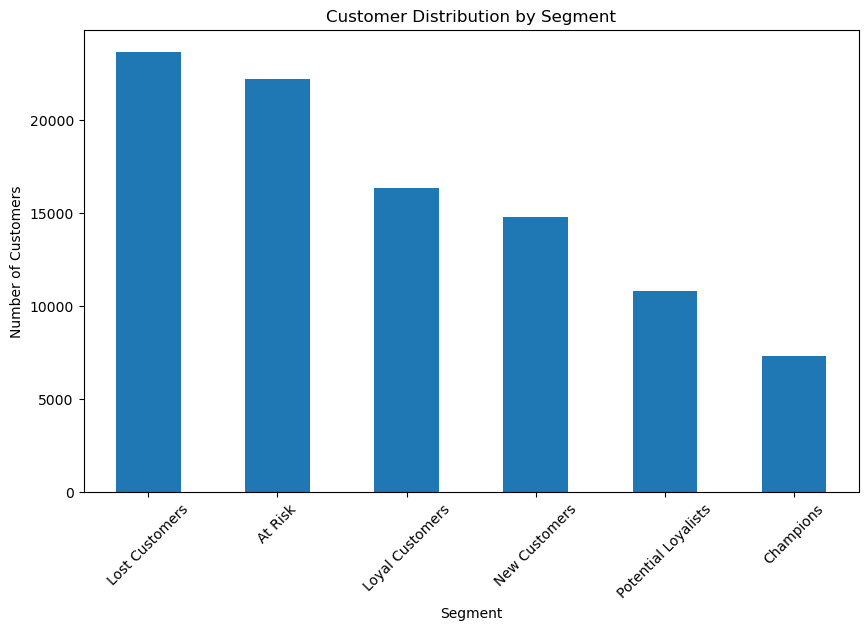

In [123]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# Revenue Contribution by Segment

Understanding which customer segments generate the highest revenue helps businesses allocate marketing resources efficiently.

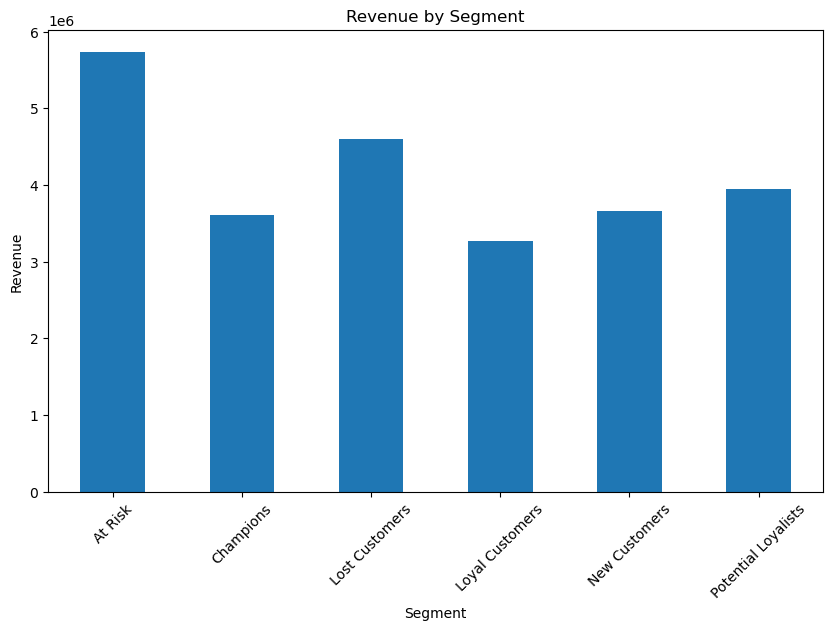

In [124]:
rfm.groupby("Segment")["Monetary"].sum().plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Revenue by Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Key Business Insights

The analysis provides several valuable business insights:

- Loyal customers contribute a significant portion of revenue.
- Champions purchase frequently and spend more.
- New customers have growth potential.
- At-risk customers require retention strategies.
- Lost customers may need re-engagement campaigns.

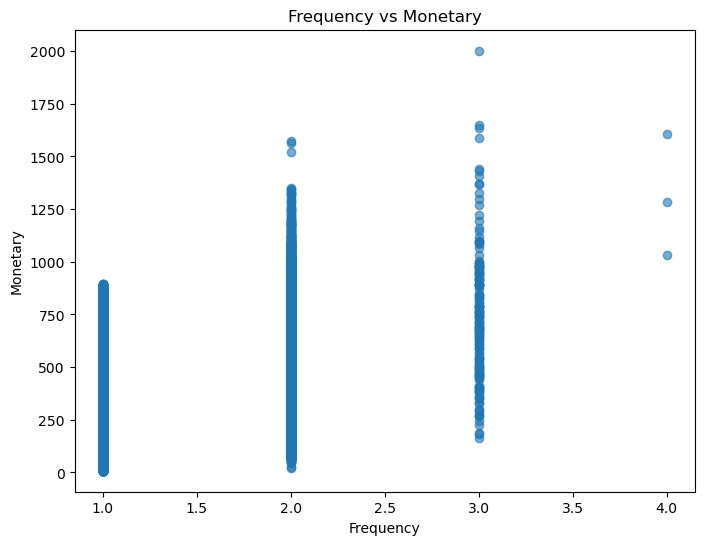

In [125]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    alpha=0.6
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Frequency vs Monetary")

plt.show()

# Marketing Recommendations

| Segment | Recommendation |
|----------|---------------|
| Champions | Exclusive rewards and VIP benefits |
| Loyal Customers | Loyalty programs and personalized offers |
| New Customers | Welcome discounts and onboarding campaigns |
| Potential Loyalists | Cross-selling and product recommendations |
| At Risk | Reactivation emails and special discounts |
| Lost Customers | Win-back campaigns with promotional offers |

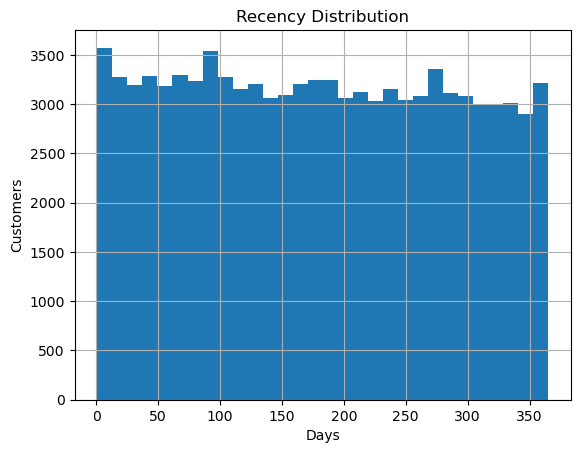

In [126]:
rfm["Recency"].hist(bins=30)

plt.title("Recency Distribution")
plt.xlabel("Days")
plt.ylabel("Customers")

plt.show()

# Conclusion

RFM Analysis effectively segments customers based on purchasing behavior.

The project demonstrates how transactional data can be transformed into actionable business insights that support marketing decisions and improve customer retention.

This analysis enables businesses to:

- Increase customer lifetime value
- Improve customer retention
- Optimize marketing campaigns
- Identify high-value customers
- Develop targeted promotional strategies

In [127]:
rfm.to_csv("RFM_Output.csv", index=True)